# Step 7 — Conformal Prediction (C3), and the C1-via-C3 test

**RESS 2025 — GAN-Conformal-RUL**

Split conformal prediction gives distribution-free, coverage-guaranteed RUL intervals. This
notebook does two things:

1. **Establishes C3 on the real-data baseline** — per-stage PICP (coverage) and MPIW (width) at
   several confidence levels, multi-seed. The overall coverage *must* hold (~1−α) by construction;
   the real question is whether **near-failure** coverage holds and at what width.
2. **Tests C1's true claim** — does GAN augmentation of *training* narrow the intervals at matched
   coverage? Point RMSE was ~flat (Step 6b); interval width can move independently. This is the
   honest test of the synergy hypothesis.

**Guards baked in:** calibration is real-only (asserted); the quantile uses the finite-sample
correction ⌈(n+1)(1−α)⌉/n; every comparison is multi-seed mean ± std; MPIW is always read next to
PICP so a narrower-but-under-covering interval is never mistaken for an improvement.

## 1. Setup

In [1]:
import os, sys, shutil
os.chdir('/content')
REPO_PATH = '/content/RESS_2025_GAN_Conformal_RUL'
if os.path.exists(REPO_PATH):
    shutil.rmtree(REPO_PATH)
!git clone https://github.com/f-khadija-benzine/RESS_2025_GAN_Conformal_RUL.git {REPO_PATH}
os.chdir(REPO_PATH)
sys.path.insert(0, REPO_PATH); sys.path.insert(0, f'{REPO_PATH}/src')
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = f'{REPO_PATH}/figures'; os.makedirs(SAVE_DIR, exist_ok=True)
CKPT_DIR = '/content/drive/MyDrive/ress_checkpoints'
import torch
print('CUDA:', torch.cuda.is_available())

Cloning into '/content/RESS_2025_GAN_Conformal_RUL'...
remote: Enumerating objects: 391, done.
remote: Counting objects: 100% (190/190), done.
remote: Compressing objects: 100% (184/184), done.
remote: Total 391 (delta 124), reused 5 (delta 5), pack-reused 201 (from 1)
Receiving objects: 100% (391/391), 8.04 MiB | 2.50 MiB/s, done.
Resolving deltas: 100% (217/217), done.
Mounted at /content/drive
CUDA: True


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

from data_loader import XJTUSYLoader
from health_indicator_v3 import HealthIndicatorPipeline
from windowing import prepare_all_folds, build_folds, WINDOW_SIZE
from model import ModelConfig, RULTrainer
from gan import StageGAN, GANConfig
from conformal import (calibrate_and_evaluate_mondrian, average_conformal_mondrian,
                       print_conformal, assert_real_calibration)

TARGET = 2
SEEDS = [1, 2, 3]                 # multi-seed per the consistency contract
ALPHAS = [0.20, 0.15, 0.10, 0.05]  # 80 / 85 / 90 / 95% intervals

[health_indicator] v2.0-guarded-fpt loaded  (FPT: 5 consecutive x max(mu+3sigma, mu*1.10))


In [3]:
import inspect, model
print('clamp' in inspect.getsource(model.RULModel.forward))

True


## 2. Data (piecewise, log_clip) + GANs

In [4]:
CANDIDATES = ['/content/drive/MyDrive/XJTU-SY',
              '/content/drive/MyDrive/XJTU-SY_Bearing_Datasets',
              '/content/drive/MyDrive/data/XJTU-SY']
DATA_ROOT = next((p for p in CANDIDATES if os.path.exists(p)), None)
assert DATA_ROOT
all_data = XJTUSYLoader(DATA_ROOT).load_all()
pipeline = HealthIndicatorPipeline(fpt_consecutive=5, fpt_min_relative_rise=0.20)
results = pipeline.process_all(all_data, verbose=False)
fold_data = prepare_all_folds(results, scaling_method='log_clip',
                              rul_target='piecewise', verbose=False)
folds = build_folds(results)

# record the real calibration sizes NOW, to guard against later leaks
CAL_SIZES = {d['fold']: len(d['y_rul_cal']) for d in fold_data}
print('real calibration sizes per fold:', CAL_SIZES)

gans = {}
for k in range(1, 6):
    ck = torch.load(f'{CKPT_DIR}/gan_fold{k}.pt',
                    map_location='cuda' if torch.cuda.is_available() else 'cpu')
    g = StageGAN(GANConfig(**ck['config']))
    g.G.load_state_dict(ck['generator']); g.D.load_state_dict(ck['critic'])
    gans[k] = g
print(f'{len(gans)}/5 GANs loaded.')


=== Condition 1: 35.0 Hz, 12.0 kN ===
Loading Bearing1_1 (1-1): 123 recordings, failure mode: Outer race
  -> Shape: (123, 32768, 2), Memory: 32.2 MB
Loading Bearing1_2 (1-2): 161 recordings, failure mode: Outer race
  -> Shape: (161, 32768, 2), Memory: 42.2 MB
Loading Bearing1_3 (1-3): 158 recordings, failure mode: Outer race
  -> Shape: (158, 32768, 2), Memory: 41.4 MB
Loading Bearing1_4 (1-4): 122 recordings, failure mode: Cage
  -> Shape: (122, 32768, 2), Memory: 32.0 MB
Loading Bearing1_5 (1-5): 52 recordings, failure mode: Outer race + Ball
  -> Shape: (52, 32768, 2), Memory: 13.6 MB

=== Condition 2: 37.5 Hz, 11.0 kN ===
Loading Bearing2_1 (2-1): 491 recordings, failure mode: Inner race
  -> Shape: (491, 32768, 2), Memory: 128.7 MB
Loading Bearing2_2 (2-2): 161 recordings, failure mode: Outer race
  -> Shape: (161, 32768, 2), Memory: 42.2 MB
Loading Bearing2_3 (2-3): 533 recordings, failure mode: Cage
  -> Shape: (533, 32768, 2), Memory: 139.7 MB
Loading Bearing2_4 (2-4): 42 re

## 3. Helpers — augmentation (training only) and a full conformal pass

In [5]:
def augment_fold(gan, d, ratio, seed=0):
    """Add synthetic S3 windows to TRAINING only. Labels sampled from real S3
    RUL (the method that removed the kNN skew in Step 6b)."""
    rng = np.random.default_rng(seed)
    Xtr, ytr, s = d['X_train'], d['y_rul_train'], d['y_stage_train']
    s3 = s == TARGET
    n_real = int(s3.sum()); n_syn = int(round(ratio * n_real))
    if n_syn == 0:
        return Xtr, ytr, s
    X_syn = gan.sample(n_syn, TARGET)
    y_syn = rng.choice(ytr[s3], size=n_syn, replace=True)
    st_syn = np.full(n_syn, TARGET, dtype=s.dtype)
    return (np.concatenate([Xtr, X_syn.astype(np.float32)]),
            np.concatenate([ytr, y_syn.astype(np.float32)]),
            np.concatenate([s, st_syn]))


def one_pass(d, cfg, seed, augment_ratio=0.0):
    """Train (optionally augmented), then run conformal at all ALPHAS.
    Returns {alpha: conformal_result_dict}. Calibration stays REAL."""
    k = d['fold']
    if augment_ratio > 0:
        Xtr, ytr, str_ = augment_fold(gans[k], d, augment_ratio, seed=seed)
    else:
        Xtr, ytr, str_ = d['X_train'], d['y_rul_train'], d['y_stage_train']

    cfg = ModelConfig(**{**cfg.__dict__, 'seed': seed})
    tr = RULTrainer(cfg)
    tr.fit(Xtr, ytr, d['X_val'], d['y_rul_val'],
           stage_train=str_, stage_val=d['y_stage_val'],
           mask_healthy=False, verbose=False)

    # GUARD: calibration must be the untouched real calibration set
    assert_real_calibration(CAL_SIZES[k], d['y_rul_cal'])

    y_cal_pred = tr.predict(d['X_cal'])
    y_test_pred = tr.predict(d['X_test'])
    return {a: calibrate_and_evaluate_mondrian(
                d['y_rul_cal'], y_cal_pred, d['y_stage_cal'],
                d['y_rul_test'], y_test_pred, d['y_stage_test'], alpha=a)
            for a in ALPHAS}

## 4. Run baseline and +GAN, multi-seed

For each seed: train all 5 folds, conformalize, average across folds. Then aggregate seeds into
mean ± std. ~2 configs × 3 seeds × 5 folds trainings; budget accordingly.

In [6]:
base_cfg = ModelConfig(epochs=100, patience=25, lr=5e-4)
AUG_RATIO = 0.75      # best setting from the Step 6b sweep

def run_config(augment_ratio):
    """Returns {alpha: {seed: fold-averaged conformal}} across seeds."""
    per_seed = {a: [] for a in ALPHAS}
    for seed in SEEDS:
        fold_res = {a: [] for a in ALPHAS}
        for d in fold_data:
            passes = one_pass(d, base_cfg, seed, augment_ratio)
            for a in ALPHAS:
                fold_res[a].append(passes[a])
        for a in ALPHAS:
             per_seed[a].append(average_conformal_mondrian(fold_res[a]))
        print(f"  seed {seed} done")
    return per_seed

print('BASELINE (real only)…')
base_seeds = run_config(augment_ratio=0.0)
print(f'+GAN (ratio {AUG_RATIO})…')
gan_seeds = run_config(augment_ratio=AUG_RATIO)

BASELINE (real only)…
  seed 1 done
  seed 2 done
  seed 3 done
+GAN (ratio 0.75)…
  seed 1 done
  seed 2 done
  seed 3 done


## 5. Aggregate seeds → mean ± std, per stage, per alpha

In [7]:
def agg(per_seed, subset, metric):
    """mean, std across seeds for one subset/metric, per alpha."""
    out = {}
    for a in ALPHAS:
        vals = [s[subset][metric] for s in per_seed[a]]
        out[a] = (float(np.mean(vals)), float(np.std(vals)))
    return out

print('C3 BASELINE — coverage should hold; near-failure is the row to watch\n')
for a in ALPHAS:
    print(f"--- target {1-a:.0%} (alpha={a}) ---")
    print(f"  {'subset':10s} {'PICP (mean±std)':>20s} {'MPIW (mean±std)':>20s}")
    for sub in ['healthy','early','nearfail','postFPT','overall']:
        pm = agg(base_seeds, sub, 'picp')[a]
        wm = agg(base_seeds, sub, 'mpiw')[a]
        print(f"  {sub:10s} {pm[0]:8.3f} ± {pm[1]:.3f}      {wm[0]:8.4f} ± {wm[1]:.4f}")
    print()

C3 BASELINE — coverage should hold; near-failure is the row to watch

--- target 80% (alpha=0.2) ---
  subset          PICP (mean±std)      MPIW (mean±std)
  healthy       0.669 ± 0.093        0.8125 ± 0.5568
  early         0.682 ± 0.035        1.1862 ± 0.2940
  nearfail      0.800 ± 0.012        0.5966 ± 0.0996
  postFPT       0.733 ± 0.014        0.9199 ± 0.2017
  overall       0.749 ± 0.045        0.8738 ± 0.4570

--- target 85% (alpha=0.15) ---
  subset          PICP (mean±std)      MPIW (mean±std)
  healthy       0.669 ± 0.093        0.8371 ± 0.5395
  early         0.711 ± 0.044        1.2341 ± 0.2951
  nearfail      0.835 ± 0.025        0.6558 ± 0.0918
  postFPT       0.764 ± 0.018        0.9737 ± 0.1985
  overall       0.762 ± 0.048        0.9110 ± 0.4441

--- target 90% (alpha=0.1) ---
  subset          PICP (mean±std)      MPIW (mean±std)
  healthy       0.669 ± 0.093        0.8748 ± 0.5130
  early         0.757 ± 0.065        1.3019 ± 0.2850
  nearfail      0.858 ± 0.027    

## 6. The C1-via-C3 test: does augmentation narrow intervals at matched coverage?

For each stage and alpha: compare baseline vs +GAN on **both** PICP and MPIW. A width reduction
only counts if coverage is preserved (PICP not lower). And the MPIW gap must exceed the seed std,
or it is within noise — a legitimate negative, exactly as Step 6b taught us.

In [8]:
print('C1-via-C3: near-failure and overall, baseline vs +GAN\n')
for a in ALPHAS:
    print(f"=== target {1-a:.0%} ===")
    for sub in ['nearfail', 'overall']:
        bp, bps = agg(base_seeds, sub, 'picp')[a]
        bw, bws = agg(base_seeds, sub, 'mpiw')[a]
        gp, gps = agg(gan_seeds,  sub, 'picp')[a]
        gw, gws = agg(gan_seeds,  sub, 'mpiw')[a]
        dw = gw - bw
        noise = np.hypot(bws, gws)      # combined seed std
        # verdict: narrower AND coverage preserved AND gap beyond noise
        if gp < bp - 0.02:
            verdict = 'GAN under-covers — width not comparable'
        elif dw < -noise:
            verdict = f'GAN NARROWER by {-dw:.4f} (> noise {noise:.4f}) — C1 helps'
        elif dw > noise:
            verdict = f'GAN WIDER by {dw:.4f} — C1 hurts'
        else:
            verdict = f'within noise ({noise:.4f}) — no effect'
        print(f"  {sub:9s} PICP {bp:.3f}->{gp:.3f} | MPIW {bw:.4f}->{gw:.4f} | {verdict}")
    print()

C1-via-C3: near-failure and overall, baseline vs +GAN

=== target 80% ===
  nearfail  PICP 0.800->0.823 | MPIW 0.5966->0.6319 | within noise (0.1220) — no effect
  overall   PICP 0.749->0.753 | MPIW 0.8738->0.9139 | within noise (0.6227) — no effect

=== target 85% ===
  nearfail  PICP 0.835->0.864 | MPIW 0.6558->0.6778 | within noise (0.1164) — no effect
  overall   PICP 0.762->0.769 | MPIW 0.9110->0.9429 | within noise (0.6088) — no effect

=== target 90% ===
  nearfail  PICP 0.858->0.895 | MPIW 0.7197->0.7303 | within noise (0.1050) — no effect
  overall   PICP 0.774->0.784 | MPIW 0.9592->0.9788 | within noise (0.5867) — no effect

=== target 95% ===
  nearfail  PICP 0.924->0.946 | MPIW 0.9593->0.9564 | within noise (0.0921) — no effect
  overall   PICP 0.799->0.808 | MPIW 1.0721->1.0838 | within noise (0.5442) — no effect



## 7. Reliability plot (baseline) — coverage vs target

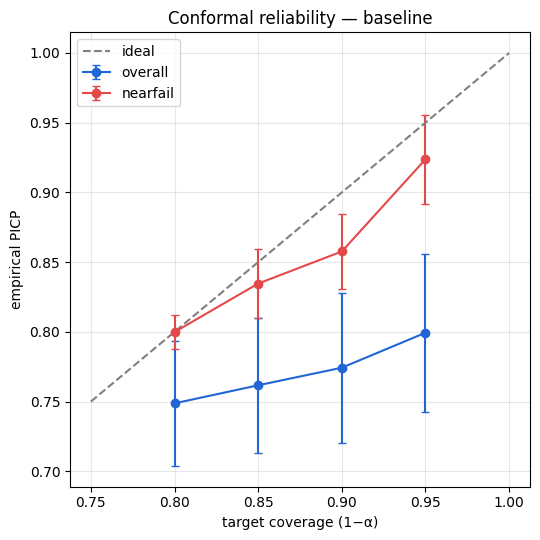

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
targets = [1 - a for a in ALPHAS]
for sub, color in [('overall','#2166d4'), ('nearfail','#e34948')]:
    picp = [agg(base_seeds, sub, 'picp')[a][0] for a in ALPHAS]
    err = [agg(base_seeds, sub, 'picp')[a][1] for a in ALPHAS]
    ax.errorbar(targets, picp, yerr=err, marker='o', label=sub, color=color, capsize=3)
ax.plot([0.75,1.0],[0.75,1.0], ls='--', color='gray', label='ideal')
ax.set_xlabel('target coverage (1−α)'); ax.set_ylabel('empirical PICP')
ax.set_title('Conformal reliability — baseline')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/07_reliability_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
d = fold_data[0]
tr = RULTrainer(ModelConfig(epochs=100, patience=25, lr=5e-4, seed=1))
tr.fit(d['X_train'], d['y_rul_train'], d['X_val'], d['y_rul_val'],
       stage_train=d['y_stage_train'], stage_val=d['y_stage_val'],
       mask_healthy=False, verbose=False)

y_cal_pred = tr.predict(d['X_cal'])
res = np.abs(d['y_rul_cal'] - y_cal_pred)
st_cal = d['y_stage_cal']

import numpy as np
print("Calibration residuals by stage:")
for s, name in [(0,'healthy'),(1,'early'),(2,'nearfail')]:
    m = st_cal == s
    if m.sum():
        print(f"  {name:10s} n={m.sum():4d}  residual mean {res[m].mean():.4f}  "
              f"90th pctile {np.percentile(res[m],90):.4f}")
print(f"\n  ALL       n={len(res)}  mean {res.mean():.4f}  90th {np.percentile(res,90):.4f}")
print(f"\nStage mix in CALIBRATION: {[int((st_cal==s).sum()) for s in (0,1,2)]}")
print(f"Stage mix in TEST:        {[int((d['y_stage_test']==s).sum()) for s in (0,1,2)]}")

Calibration residuals by stage:
  healthy    n=1477  residual mean 0.2080  90th pctile 0.5386
  early      n= 155  residual mean 0.3709  90th pctile 0.6367
  nearfail   n= 160  residual mean 0.1832  90th pctile 0.3578

  ALL       n=1792  mean 0.2199  90th 0.5480

Stage mix in CALIBRATION: [1477, 155, 160]
Stage mix in TEST:        [2805, 155, 99]


In [11]:
yp_cal = tr.predict(d['X_cal'])
m = d['y_stage_cal'] == 0  # healthy
print(f"Healthy calibration windows (true RUL should be 1.0 under piecewise):")
print(f"  true RUL:  mean {d['y_rul_cal'][m].mean():.3f}  range [{d['y_rul_cal'][m].min():.3f}, {d['y_rul_cal'][m].max():.3f}]")
print(f"  pred RUL:  mean {yp_cal[m].mean():.3f}  range [{yp_cal[m].min():.3f}, {yp_cal[m].max():.3f}]")
print(f"  pred std:  {yp_cal[m].std():.3f}")

Healthy calibration windows (true RUL should be 1.0 under piecewise):
  true RUL:  mean 1.000  range [1.000, 1.000]
  pred RUL:  mean 0.792  range [0.223, 1.000]
  pred std:  0.213


In [12]:
# What's the model's raw output before sigmoid? Is sigmoid saturating?
# Quick proxy: how many healthy preds are stuck below 0.9?
m = d['y_stage_cal'] == 0
yp = tr.predict(d['X_cal'])[m]
print(f"healthy preds: {(yp<0.9).mean():.1%} below 0.9, {(yp<0.7).mean():.1%} below 0.7")
print(f"if most are jammed at 0.7-0.9, sigmoid is struggling to reach 1.0")

healthy preds: 57.9% below 0.9, 30.7% below 0.7
if most are jammed at 0.7-0.9, sigmoid is struggling to reach 1.0


In [13]:
for d in fold_data:
    cst = d['y_stage_cal']
    print(f"fold {d['fold']}: cal healthy={int((cst==0).sum())} "
          f"early={int((cst==1).sum())} nearfail={int((cst==2).sum())}")

fold 1: cal healthy=1477 early=155 nearfail=160
fold 2: cal healthy=407 early=228 nearfail=207
fold 3: cal healthy=1207 early=713 nearfail=675
fold 4: cal healthy=2385 early=128 nearfail=121
fold 5: cal healthy=153 early=225 nearfail=215


In [14]:
# Per-fold near-failure PICP at target 90% — is the undershoot consistent or one bad fold?
import numpy as np
from conformal import calibrate_and_evaluate_mondrian
cfg = ModelConfig(epochs=100, patience=25, lr=5e-4, seed=1)
print("Per-fold near-failure PICP (target 0.90):")
for d in fold_data:
    tr = RULTrainer(cfg)
    tr.fit(d['X_train'], d['y_rul_train'], d['X_val'], d['y_rul_val'],
           stage_train=d['y_stage_train'], stage_val=d['y_stage_val'],
           mask_healthy=False, verbose=False)
    r = calibrate_and_evaluate_mondrian(
        d['y_rul_cal'], tr.predict(d['X_cal']), d['y_stage_cal'],
        d['y_rul_test'], tr.predict(d['X_test']), d['y_stage_test'], alpha=0.1)
    nf = r['nearfail']
    print(f"  fold {d['fold']}: PICP {nf['picp']:.3f}  MPIW {nf['mpiw']:.3f}  "
          f"n_test_nf={nf['n']}  q={nf['q']:.3f}")

Per-fold near-failure PICP (target 0.90):
  fold 1: PICP 0.939  MPIW 0.730  n_test_nf=99  q=0.365
  fold 2: PICP 0.988  MPIW 0.409  n_test_nf=692  q=0.205
  fold 3: PICP 0.746  MPIW 0.641  n_test_nf=252  q=0.321
  fold 4: PICP 0.699  MPIW 1.023  n_test_nf=73  q=0.512
  fold 5: PICP 0.735  MPIW 0.480  n_test_nf=117  q=0.240


In [16]:
import numpy as np
from model import evaluate_grid, average_grids, secondary_metrics
from conformal import calibrate_and_evaluate_mondrian, average_conformal_mondrian

SEEDS = [1, 2, 3,4,5]
ALPHA = 0.10   # 90% intervals for the headline conformal number

def test_bearing_ids(fold):
    bids = []
    for bid in fold['test']:
        n = results[bid]['features'].shape[0]
        bids.extend([bid] * max(0, n - WINDOW_SIZE + 1))
    return np.array(bids)

def full_eval(augment_ratio):
    """Returns per-seed lists of (grid, conformal) averaged over folds."""
    grids_per_seed, conf_per_seed = [], []
    for seed in SEEDS:
        cfg = ModelConfig(epochs=100, patience=25, lr=5e-4, seed=seed)
        fold_grids, fold_conf = [], []
        for d, f in zip(fold_data, folds):
            k = d['fold']
            if augment_ratio > 0:
                Xtr, ytr, str_ = augment_fold(gans[k], d, augment_ratio, seed=seed)
            else:
                Xtr, ytr, str_ = d['X_train'], d['y_rul_train'], d['y_stage_train']
            tr = RULTrainer(cfg)
            tr.fit(Xtr, ytr, d['X_val'], d['y_rul_val'],
                   stage_train=str_, stage_val=d['y_stage_val'],
                   mask_healthy=False, verbose=False)
            yp_test = tr.predict(d['X_test'])
            bids = test_bearing_ids(f)
            fold_grids.append(evaluate_grid(d['y_rul_test'], yp_test,
                                            d['y_stage_test'], bids))
            fold_conf.append(calibrate_and_evaluate_mondrian(
                d['y_rul_cal'], tr.predict(d['X_cal']), d['y_stage_cal'],
                d['y_rul_test'], yp_test, d['y_stage_test'], alpha=ALPHA))
        grids_per_seed.append(average_grids(fold_grids))
        conf_per_seed.append(average_conformal_mondrian(fold_conf))
        print(f"  seed {seed} done")
    return grids_per_seed, conf_per_seed

def summarize(grids, confs, label):
    """Mean ± std across seeds for the key metrics."""
    def ms(vals): return f"{np.mean(vals):.4f} ± {np.std(vals):.4f}"
    print(f"\n{'='*58}\n{label} (mean ± std over {len(SEEDS)} seeds)\n{'='*58}")
    print("RMSE (normalised, per-bearing):")
    for sub in ['nearfail', 'postFPT', 'overall']:
        print(f"  {sub:9s} {ms([g[sub]['per_bearing'] for g in grids])}")
    print("Near-failure conformal (target 90%):")
    print(f"  PICP      {ms([c['nearfail']['picp'] for c in confs])}")
    print(f"  MPIW      {ms([c['nearfail']['mpiw'] for c in confs])}")

print('BASELINE…')
b_grids, b_confs = full_eval(0.0)
print('+GAN (ratio 0.75)…')
g_grids, g_confs = full_eval(0.75)

summarize(b_grids, b_confs, 'BASELINE')
summarize(g_grids, g_confs, '+GAN r=0.75')

BASELINE…
  seed 1 done
  seed 2 done
  seed 3 done
  seed 4 done
  seed 5 done
+GAN (ratio 0.75)…
  seed 1 done
  seed 2 done
  seed 3 done
  seed 4 done
  seed 5 done

BASELINE (mean ± std over 5 seeds)
RMSE (normalised, per-bearing):
  nearfail  0.2438 ± 0.0180
  postFPT   0.4025 ± 0.1074
  overall   0.4598 ± 0.2187
Near-failure conformal (target 90%):
  PICP      0.8587 ± 0.0241
  MPIW      0.7208 ± 0.0880

+GAN r=0.75 (mean ± std over 5 seeds)
RMSE (normalised, per-bearing):
  nearfail  0.2384 ± 0.0149
  postFPT   0.3899 ± 0.1151
  overall   0.4449 ± 0.2270
Near-failure conformal (target 90%):
  PICP      0.8854 ± 0.0132
  MPIW      0.7271 ± 0.0789


In [17]:
import numpy as np
from conformal import calibrate_and_evaluate_mondrian

SEEDS = [1, 2, 3, 4, 5]
ALPHA = 0.10

def per_fold_picp(augment_ratio):
    """Returns {fold: (mean_picp, std_picp, mean_mpiw)} over seeds, near-failure."""
    acc = {d['fold']: {'picp': [], 'mpiw': []} for d in fold_data}
    for seed in SEEDS:
        cfg = ModelConfig(epochs=100, patience=25, lr=5e-4, seed=seed)
        for d in fold_data:
            k = d['fold']
            if augment_ratio > 0:
                Xtr, ytr, str_ = augment_fold(gans[k], d, augment_ratio, seed=seed)
            else:
                Xtr, ytr, str_ = d['X_train'], d['y_rul_train'], d['y_stage_train']
            tr = RULTrainer(cfg)
            tr.fit(Xtr, ytr, d['X_val'], d['y_rul_val'],
                   stage_train=str_, stage_val=d['y_stage_val'],
                   mask_healthy=False, verbose=False)
            r = calibrate_and_evaluate_mondrian(
                d['y_rul_cal'], tr.predict(d['X_cal']), d['y_stage_cal'],
                d['y_rul_test'], tr.predict(d['X_test']), d['y_stage_test'],
                alpha=ALPHA)['nearfail']
            acc[k]['picp'].append(r['picp'])
            acc[k]['mpiw'].append(r['mpiw'])
        print(f"  seed {seed} done")
    return acc

print('BASELINE per-fold…')
base_pf = per_fold_picp(0.0)
print('+GAN per-fold…')
gan_pf = per_fold_picp(0.75)

print(f"\n{'='*66}")
print(f"Per-fold near-failure PICP (target {1-ALPHA:.0%}), mean±std over {len(SEEDS)} seeds")
print(f"{'='*66}")
print(f"{'fold':6s} {'baseline PICP':>18s} {'+GAN PICP':>18s} {'Δ':>8s}")
for d in fold_data:
    k = d['fold']
    bp = np.mean(base_pf[k]['picp']); bps = np.std(base_pf[k]['picp'])
    gp = np.mean(gan_pf[k]['picp']);  gps = np.std(gan_pf[k]['picp'])
    flag = '  ← was under' if bp < 0.85 else ''
    print(f"{k:6d} {bp:8.3f} ± {bps:.3f}   {gp:8.3f} ± {gps:.3f}   {gp-bp:+.3f}{flag}")

BASELINE per-fold…
  seed 1 done
  seed 2 done
  seed 3 done
  seed 4 done
  seed 5 done
+GAN per-fold…
  seed 1 done
  seed 2 done
  seed 3 done
  seed 4 done
  seed 5 done

Per-fold near-failure PICP (target 90%), mean±std over 5 seeds
fold        baseline PICP          +GAN PICP        Δ
     1    0.962 ± 0.021      0.947 ± 0.040   -0.014
     2    0.951 ± 0.051      0.936 ± 0.043   -0.015
     3    0.877 ± 0.088      0.942 ± 0.045   +0.065
     4    0.759 ± 0.085      0.764 ± 0.090   +0.005  ← was under
     5    0.745 ± 0.042      0.838 ± 0.027   +0.092  ← was under


## Reading this

- **Overall PICP ≈ target** confirms the conformal implementation is correct (guaranteed by
  construction on exchangeable data). If it's far off, suspect a calibration leak or a broken split.
- **near-failure PICP < target** would mean coverage fails exactly where it matters — a real,
  reportable finding about the limits of exchangeability in the degraded regime.
- **C1 verdict:** if +GAN narrows near-failure MPIW beyond the seed noise *without* dropping PICP,
  C1 stands on its true (conformal) claim. If within noise, C1 is a controlled negative and the
  paper rests on C2 (multi-task) and C3 (calibrated intervals) — a legitimate outcome.